In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from irsa.io import load_spectra
from irsa.spectra import SpectraCollection
from irsa.spectra.objects import smooth_pca

import mlgrad.smooth as smooth
import mlgrad.af as af
import mlgrad.funcs as funcs
import mlgrad.inventory as inventory

import ipywidgets

import warnings
warnings.filterwarnings( "ignore") #, module = "matplotlib\..*")

# %matplotlib widget

In [2]:
softabs_func = funcs.SoftAbs(0.001)
abs_func = funcs.Abs()
sq_func = funcs.Square()

In [3]:
dd = SpectraCollection()
dd.load("/home/intellimath/work/spectra/13", "origin")
keys = list(dd.keys())
x = dd[keys[0]].x
ys = dd[keys[0]].y
y = ys[0]
# y_max = y.max()
# y /= y_max

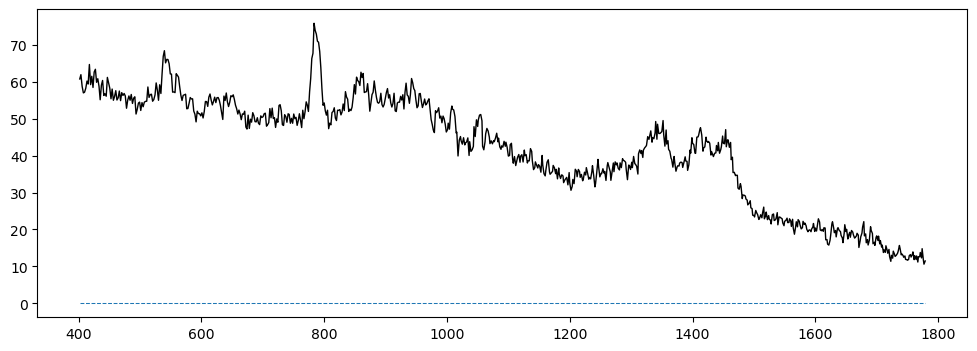

In [4]:
plt.figure(figsize=(12,4))
plt.plot(x, y, color='k', linewidth=1.0)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.show()

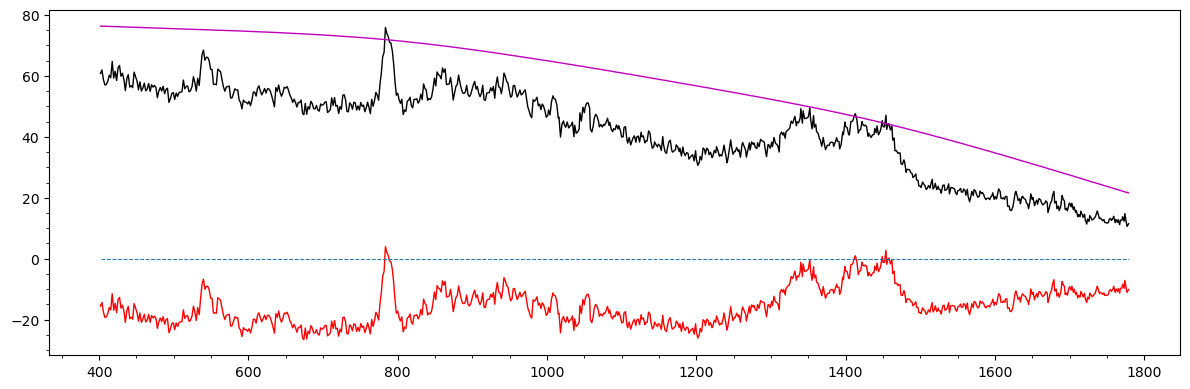

In [5]:
bl, _ = smooth.whittaker_smooth_weight_func2(
        y,
        # func=funcs.softlog_div,
        func=funcs.Step(0.00, eps=0.001),
        # func2=funcs.Step(0.00, eps=0.001),
        # func2_e=inventory.relative_abs_max,
        tau2=1.0e6, d=2)
y_bl = y - bl
y_bl -= y_bl.min()
# y_bl /= y_bl.mean()
# y_bl *= 10
plt.figure(figsize=(12,4))
plt.plot(x, y, color='k', linewidth=1.0)
plt.plot(x, bl, color='m', linewidth=1.0)
plt.plot(x, y-bl, color='r', linewidth=1.0)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.tight_layout()
plt.minorticks_on()
plt.show()

In [6]:
from irsa.spectra.objects import despike

alpha_slider = ipywidgets.FloatSlider(value=0.1, min=0.0, max=5.0, step=0.1, readout_format=".1f")
alpha_slider.layout.width="50%"

xrange_slider = ipywidgets.FloatRangeSlider(
                value=(x.min(), x.max()),
                min=x.min(),
                max=x.max())
xrange_slider.layout.width="80%"

@ipywidgets.interact(alpha=alpha_slider, xrange=xrange_slider, continuous_update=False)
def plot_despike(alpha, xrange):
    plt.figure(figsize=(12,4))
    plt.plot(x, y_bl, color='m', linewidth=1.0, marker='o', markersize=2)
    plt.plot(x, despike(y_bl, alpha), color='k', linewidth=1.0)
    plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
    plt.tight_layout()
    plt.minorticks_on()
    plt.xlim(*xrange)
    plt.show()

interactive(children=(FloatSlider(value=0.1, description='alpha', layout=Layout(width='50%'), max=5.0, readout…

In [7]:
tau2_slider = ipywidgets.FloatSlider(value=0.1, min=0, max=10, step=0.1, readout_format=".4f")
tau2_slider.layout.width="50%"
alpha_slider = ipywidgets.FloatSlider(value=0.1, min=0.0, max=5.0, step=0.1, readout_format=".3f")
alpha_slider.layout.width="50%"

@ipywidgets.interact(tau2=tau2_slider, alpha=alpha_slider, continuous_update=False)
def plot_despike(tau2, alpha):
    y_bl_sm, _ = smooth.whittaker_smooth_ex(y_bl, tau2=tau2,
                                            aggfunc=af.averaging_function("WMZ", kwds={"alpha":alpha}),
                                            func2_e=inventory.relative_abs_max,
                                            )
    y_bl2 = smooth.whittaker_smooth(y_bl, tau2=tau2)
    plt.figure(figsize=(12,4))
    plt.plot(x, y_bl, color='k', marker='s', ms=2.0, linewidth=0.1)
    plt.plot(x, y_bl_sm, color='k', linewidth=1.0, label="WH Step")
    plt.plot(x, y_bl2, color='b', linewidth=1.0, label="WH")
    plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
    plt.tight_layout()
    plt.minorticks_on()
    plt.grid(ls=':', lw=0.75)
    plt.xlim(500,1100)
    plt.legend()
    plt.show()
    
    # plt.figure(figsize=(12,4))
    # plt.hlines(alpha, 0, len(y_bl), lw=1.0, ls='--')
    # plt.plot(sorted(abs(inventory.modified_zscore(abs(y_bl - y_bl_sm)))))
    # plt.minorticks_on()
    # plt.grid(ls=':', lw=0.75)
    # plt.show()

interactive(children=(FloatSlider(value=0.1, description='tau2', layout=Layout(width='50%'), max=10.0, readout…

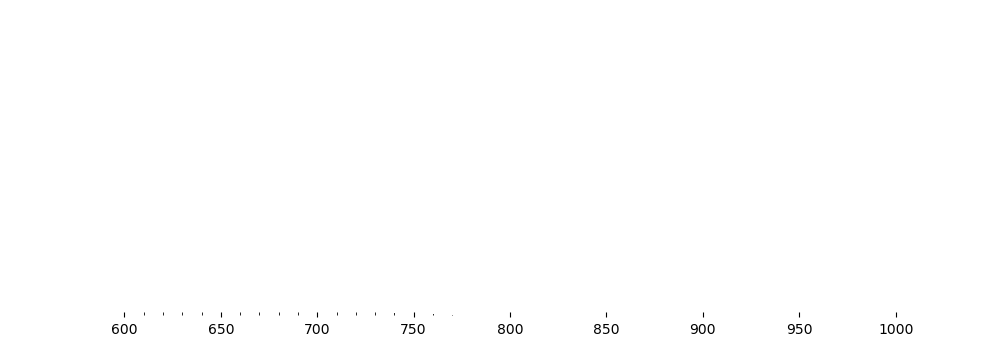

In [8]:
plt.figure(figsize=(12,4))
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=1.0)
plt.vlines(x, 0, y_bl, color='k', linewidth=0.1)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.xlim(600,1000)
plt.tight_layout()
plt.minorticks_on()
plt.show()

In [9]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,-0.2,0,0.2,2],[1,1,0.5,0,0], color='k')
plt.xticks([-2,-0.2,0, 0.2,2],['',r'$-\delta$', 0, r'$\delta$', ''])
plt.yticks([1,0.5,0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_delta.eps")
plt.show()

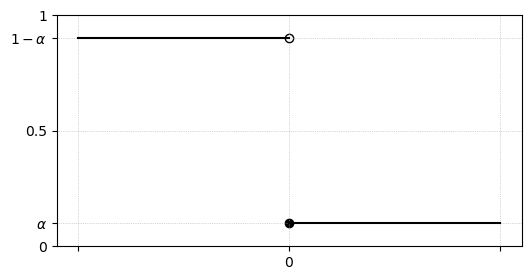

In [10]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,0],[0.9,0.9], color='k')
plt.plot([0,2],[0.1,0.1], color='k')
plt.scatter([0],[0.1], c='k')
plt.scatter([0],[0.9], c='w', edgecolors='k')
plt.xticks([-2,0,2],['', 0,  ''])
plt.yticks([1, 0.9,0.5,0.1,0], [1,r'$1-\alpha$',0.5,r'$\alpha$',0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/expectile.eps")
plt.show()

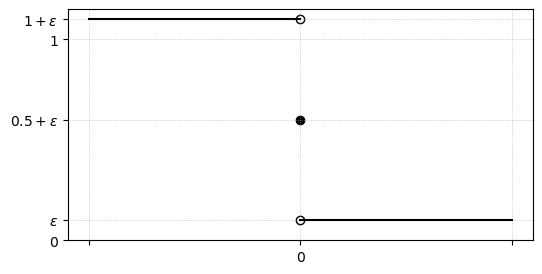

In [11]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,0],[1.1,1.1], color='k')
plt.plot([0,2],[0.1,0.1], color='k')
plt.scatter([0],[0.6], c='k')
plt.scatter([0,0],[0.1, 1.1], c='w', edgecolors='k')
plt.xticks([-2,0,2],['', 0,  ''])
plt.yticks([1.1, 1,0.6,0.1,0], [r'$1+\epsilon$',1,r'$0.5+\epsilon$',r'$\epsilon$',0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_epsilon.eps")
plt.show()

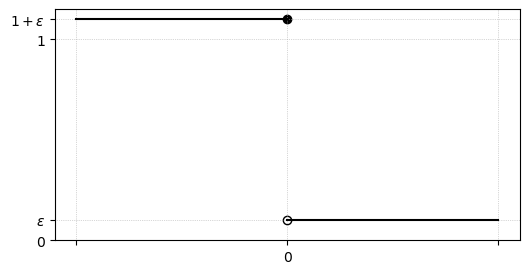

In [12]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,0],[1.1,1.1], color='k')
plt.plot([0,2],[0.1,0.1], color='k')
plt.scatter([0],[1.1], c='k')
plt.scatter([0],[0.1], c='w', edgecolors='k')
plt.xticks([-2,0,2],['', 0,  ''])
plt.yticks([1.1, 1,0.1,0], [r'$1+\epsilon$',1,r'$\epsilon$',0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_epsilon1.eps")
plt.show()

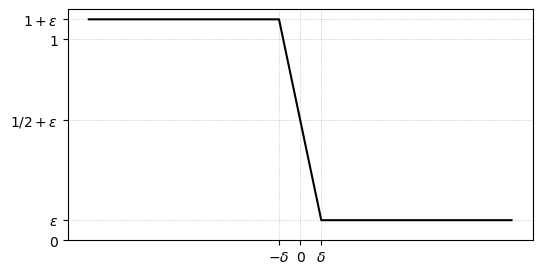

In [13]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,-0.2,0,0.2,2],[1.1, 1.1, 0.6, 0.1, 0.1], color='k')
plt.xticks([-0.2, 0, 0.2],[r'$-\delta$', 0,  r'$\delta$'])
plt.yticks([0, 0.1, 0.6, 1, 1.1], [0, r'$\epsilon$', r'$1/2+\epsilon$', 1, r'$1+\epsilon$'])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_linear_epsilon.eps")
plt.show()

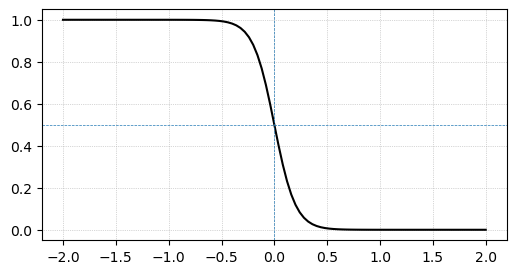

In [14]:
plt.figure(figsize=(6,3.0))
xr = np.linspace(-2,2,101)
plt.plot(xr,funcs.Logistic(-0.1).evaluate_array(xr), color='k')
plt.axhline(0.5, lw=0.5, ls='--')
plt.axvline(0, lw=0.5, ls='--')
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_expit.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


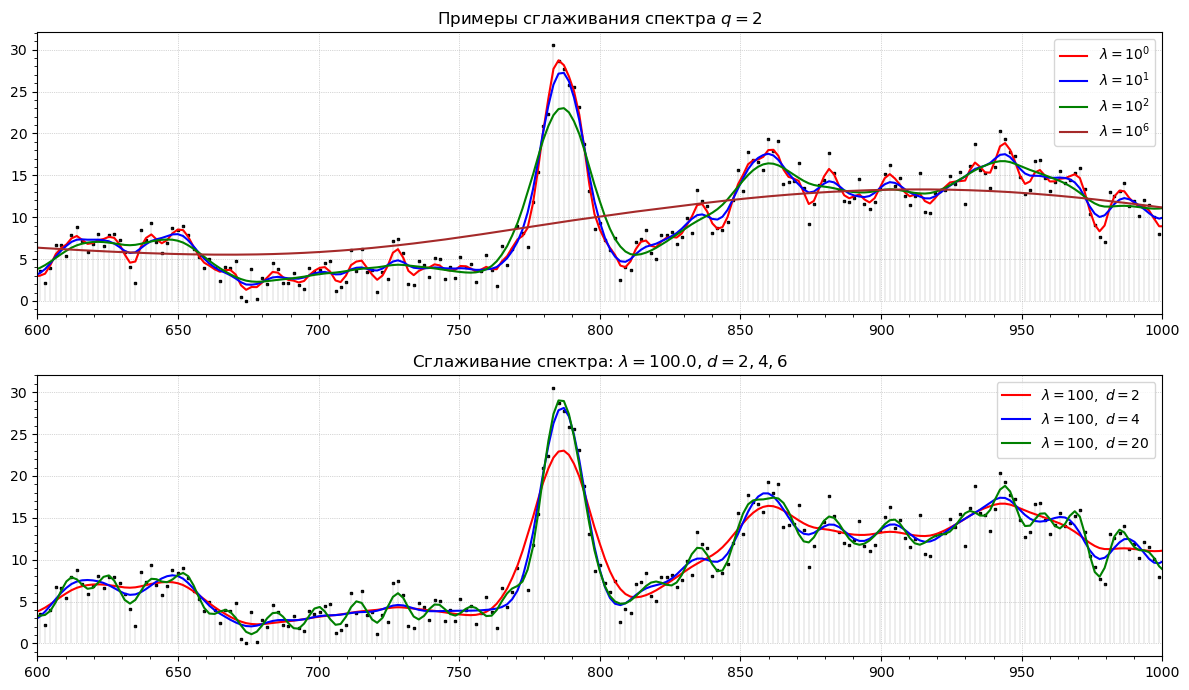

In [15]:
js = [0, 1, 2, 6]
colors1 = ["red", "blue", "green", "brown", "margenta"]
colors2 = ["darkred", "darkblue", "darkgreen", "magenta"]
zs = [smooth.whittaker_smooth(y_bl, tau2=10**j, d=2) for j in js]

ds = [2,4,20]
zs1 = [smooth.whittaker_smooth(y_bl, tau2=100.0, d=d) for d in ds]

plt.figure(figsize=(12,7))
plt.subplot(2,1,1)
plt.title(r"Примеры сглаживания спектра $q=2$")
# plt.plot(x, y_bl, color='gray', linewidth=0.5, marker='o', ms=1.0, label="оригинал")
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=2.0)
plt.vlines(x, 0, y_bl, color='gray', linewidth=0.2)
for i,z in enumerate(zs):
    plt.plot(x, z, color=colors1[i],  linewidth=1.5, label=r"$\lambda=$"+ r"$10^{%s}$" % js[i])
# plt.xlabel("t")
# plt.ylabel("x")
plt.xlim(600,1000)
plt.minorticks_on()
plt.tight_layout()
plt.grid(ls=':', lw=0.5)
plt.legend()
plt.subplot(2,1,2)
plt.title(r"Сглаживание спектра: $\lambda=100.0$, $d=2,4,6$")
# plt.plot(x, y_bl, color='gray', linewidth=0.5, marker='o', ms=1.0, label="оригинал")
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=2.0)
plt.vlines(x, 0, y_bl, color='gray', linewidth=0.2)
for i,z in enumerate(zs1):
    plt.plot(x, z, color=colors1[i], linewidth=1.5, label=r"$\lambda=100,\ d=$" + f"{ds[i]}")
plt.minorticks_on()
plt.tight_layout()
plt.xlim(600,1000)
plt.legend()
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/smooth1.eps")
plt.show()

In [16]:
# ds = [2,4,6]
# colors1 = ["red", "blue", "green"]
# colors2 = ["darkred", "darkblue", "darkgreen"]
# softabs_func = funcs.SoftAbs(0.00001)
# sq_func = funcs.Square()
# # func_lc = funcs.LinearComp(sq_func, softabs_func, 0.1, 1.0)
# abs_func = funcs.Abs()
# zs = [smooth.whittaker_smooth_weight_func2(y_bl, tau2=0.5, 
#                                             func=softabs_func.derivative_div_array, 
#                                             func2=softabs_func.derivative_div_array, 
#                                             d=d)[0] \
#      for d in ds]

# plt.figure(figsize=(12,4))
# plt.title(r"Сглаживание спектра: $\varrho(z)=\eta(z)=|z|_\epsilon$,  $\lambda=1$, $q=2,4,6$")
# plt.plot(x, y_bl, color='k', linewidth=0.25, marker='s', ms=2.0, label="оригинал")
# for i,z in enumerate(zs):
#     plt.plot(x, z, color=colors1[i], linewidth=1.0, label=r"$d=$" + f"{ds[i]}")
# # plt.xlabel("t")
# # plt.ylabel("x")
# plt.minorticks_on()
# plt.tight_layout()
# plt.xlim(600,1000)
# plt.legend()
# plt.grid(ls=':', lw=0.5)
# plt.show()

In [17]:
# ds = [2,4,6]
# colors1 = ["red", "blue", "green"]
# # colors2 = ["darkred", "darkblue", "darkgreen"]
# softabs_func = funcs.SoftAbs(0.00001)
# sq_func = funcs.Square()
# abs_func = funcs.Abs()

# def gauss_func2(Z, s=5):
#     return np.exp(-2*abs(Z) / s)

# zs1, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, d=2)
# zs2, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, func2_e=inventory.relative_abs_max, d=2)
# plt.figure(figsize=(12,4))
# plt.title(r"Сглаживание спектра: $\varrho(z)=\eta(z)=|z|_\epsilon$,  $\lambda=1$, $q=2,4,6$")
# plt.plot(x, y_bl, color='k', linewidth=0.25, marker='o', ms=1.0, label="оригинал")
# plt.plot(x, zs1, color="r", linewidth=1.0, label="1")
# plt.plot(x, zs2, color="b", linewidth=1.0, label="2")
# # plt.xlabel("t")
# # plt.ylabel("x")
# plt.minorticks_on()
# plt.tight_layout()
# plt.xlim(600,1000)
# plt.legend()
# plt.grid(ls=':', lw=0.5)
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


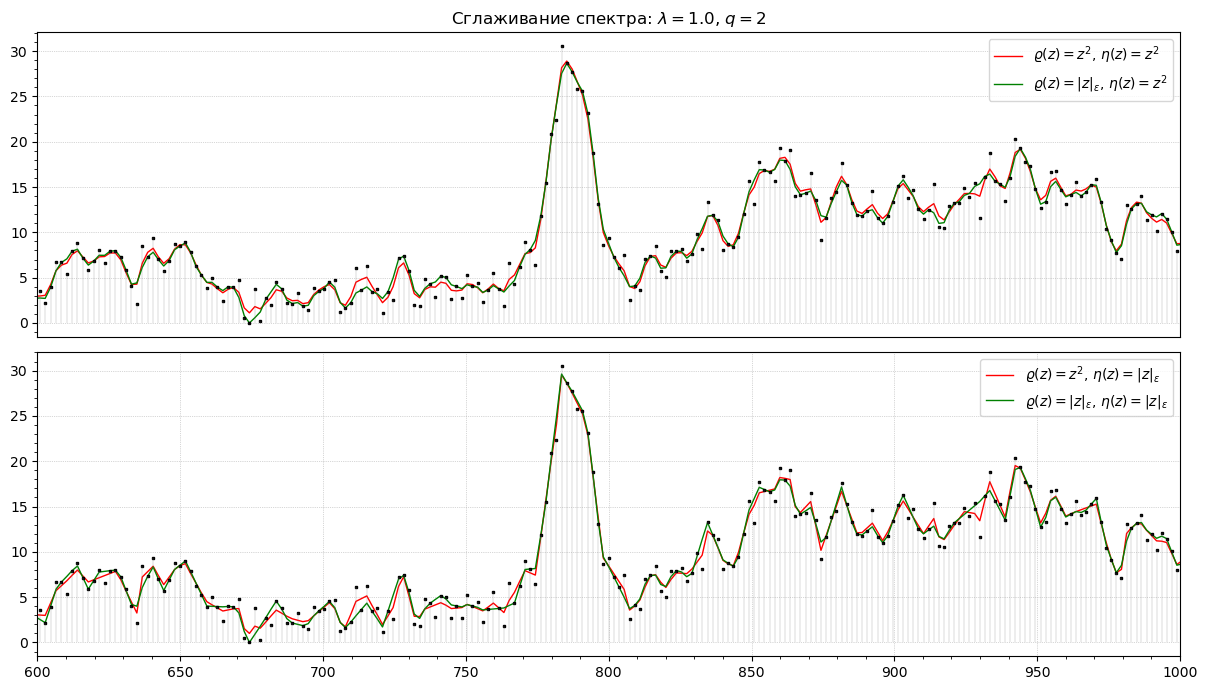

In [18]:
tau = 0.5
d=2

z1 = smooth.whittaker_smooth(y_bl, tau2=tau, d=d)
z2, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=tau, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=sq_func.derivative_div_array, 
                                          d=d)

z3, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=tau, 
                                          func=sq_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=d)
z4, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=tau, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=d)

plt.figure(figsize=(12,7))
plt.subplot(2,1,1)
plt.plot(x, z1, lw=1.0, color='r', 
         label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
plt.plot(x, z2, lw=1.0, color='g', 
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=z^2$")
# plt.plot(x, y_bl, color='k', lw=0.2, marker='o', ms=2, label='spectra')
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=2.0)
plt.vlines(x, 0, y_bl, color='gray', linewidth=0.2)
plt.title(r"Сглаживание спектра: $\lambda=1.0$, $q=2$")
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xticks([])
plt.xlim(600,1000)
plt.subplot(2,1,2)
plt.plot(x, z3, lw=1.0, color='r', 
         label=r"$\varrho(z)=z^2$, $\eta(z)=|z|_\epsilon$")
plt.plot(x, z4, lw=1.0, color='g', 
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
# plt.plot(x, y_bl, color='k', lw=0.2, marker='o', ms=2, label='spectra')
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=2.0)
plt.vlines(x, 0, y_bl, color='gray', linewidth=0.2)
# plt.title(r"Сглаживание спектра: $\lambda=1.0$, $q=2$")
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xlim(600,1000)
plt.savefig("fig/smooth2.eps")
plt.show()
# plt.figure(figsize=(10,3))
# plt.plot(sorted(abs(inventory.zscore(abs(z-y_bl)))), color="r", label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
# plt.plot(sorted(abs(inventory.zscore(abs(z2-y_bl)))), color="g", label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
# plt.hlines(3.0, 0, len(y_bl), ls='--')
# plt.hlines(3.5, 0, len(y_bl), ls='--')
# plt.legend()
# plt.tight_layout()
# plt.minorticks_on()
# plt.grid(ls=':', lw=0.5)
# plt.show()

100


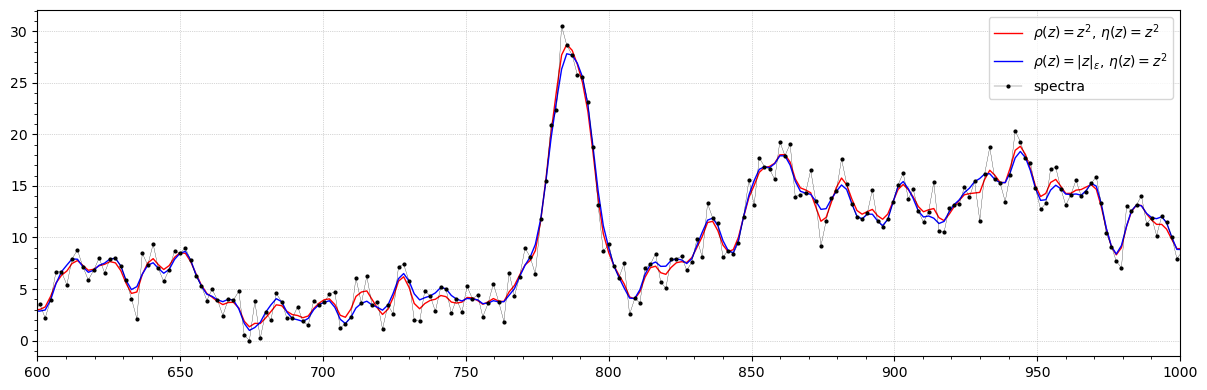

In [19]:
softabs_func = funcs.SoftAbs(1.0e-6)
sq_func = funcs.Square()
tau = 1.0

z2, d = smooth.whittaker_smooth_ex(y_bl, tau2=tau, 
                            func=softabs_func,
                            func2=sq_func,
                            d=2)
z = smooth.whittaker_smooth(y_bl, tau2=tau, d=2)
print(d["K"])

plt.figure(figsize=(12,4))
plt.plot(x, z, lw=1.0, color='r', 
         label=r"$\rho(z)=z^2$, $\eta(z)=z^2$")
plt.plot(x, z2, lw=1.0, color='b', 
         label=r"$\rho(z)=|z|_{\epsilon}$, $\eta(z)=z^2$")
plt.plot(x, y_bl, color='k', lw=0.2, marker='o', ms=2, label='spectra')
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xlim(600,1000)
plt.show()
# plt.figure(figsize=(10,4))
# plt.plot(sorted(abs(inventory.modified_zscore(abs(z-y_bl)))), color='r', label=r"$\rho(z)=z^2$, $\eta(z)=z^2$")
# plt.plot(sorted(abs(inventory.modified_zscore(abs(z2-y_bl)))), color='g', label=r"$WMZ$, $\eta(z)=z^2$")
# plt.hlines(3.0, 0, len(y_bl), ls='--')
# plt.hlines(3.5, 0, len(y_bl), ls='--')
# plt.legend()
# plt.tight_layout()
# plt.minorticks_on()
# plt.grid(ls=':', lw=0.5)
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


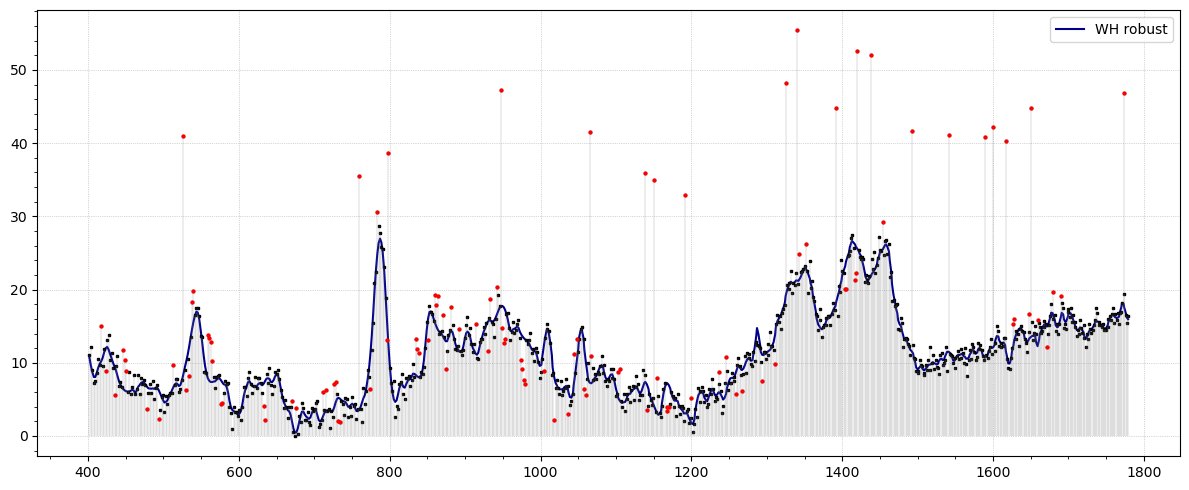

In [20]:
from mlgrad.af import averaging_function
softabs_func = funcs.SoftAbs(0.00001)
sq_func = funcs.Square()
tau = 1.0

ii = np.random.randint(0,len(x)-1, 20)
y_bl2 = y_bl.copy()
y_bl2[ii] += 30

alpha = 3.5
aggfunc = averaging_function("WMZ", kwds={"alpha":alpha})
z2, _ = smooth.whittaker_smooth_ex(y_bl2, tau2=tau, 
                            aggfunc=aggfunc,
                            # aggfunc2=averaging_function("AM"),
                            # func=funcs.Abs(),
                            func=sq_func,
                            func2=sq_func,
                            d=2)

# tt = aggfunc.mavr.u + (alpha/0.6748) * aggfunc.savr.u
# mask = (sq_func.evaluate_array(z2 - y_bl2) >= tt)
mask = abs(inventory.modified_zscore(abs(z2 - y_bl2))) >= 3.5
W = np.ones_like(y_bl)
W[mask] = 0

z = smooth.whittaker_smooth(y_bl2, W=W, tau2=tau, d=2)
zz = smooth.whittaker_smooth(y_bl, tau2=tau, d=2)


plt.figure(figsize=(12,5))
# plt.plot(x, zz, lw=1.0, ls='--', color='k', label='WH with outliers')
# plt.plot(x, z, lw=1.0, color='b', 
         # label=r"WH no outliers")
plt.plot(x, z2, lw=1.5, color='darkblue', ls='-',
         label=r"WH robust")
plt.plot(x, y_bl2, color='k', lw=0, marker='s', ms=2.0)
plt.vlines(x, 0, y_bl2, color='gray', linewidth=0.2)
plt.plot(x[mask], y_bl2[mask], color='r', lw=0, marker='o', ms=2.0)
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
# plt.xlim(700,1300)
plt.savefig("fig/rob_smooth1.eps")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


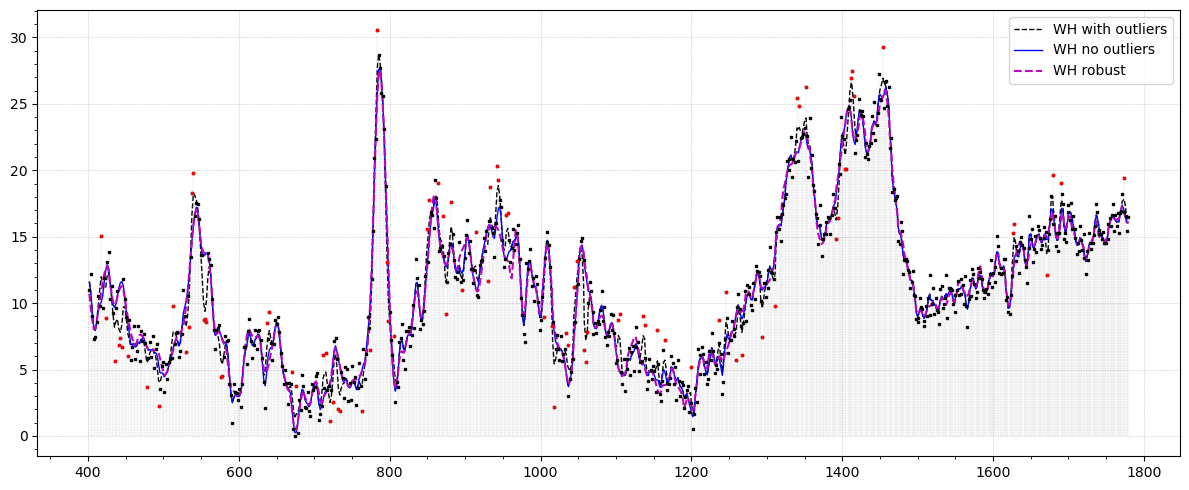

In [21]:
tau = 1.0
alpha = 3.5
aggfunc = averaging_function("WMZ", kwds={"alpha":alpha})
z2, _ = smooth.whittaker_smooth_ex(y_bl, tau2=tau, 
                            aggfunc=aggfunc,
                            # aggfunc2=averaging_function("AM"),
                            # func=funcs.Abs(),
                            func=sq_func,
                            func2=sq_func,
                            d=2)

# tt = aggfunc.mavr.u + (alpha/0.6748) * aggfunc.savr.u
# mask = (sq_func.evaluate_array(z2 - y_bl) >= tt)
mask = abs(inventory.modified_zscore(abs(z2 - y_bl))) >= 3.5
W = np.ones_like(y_bl)
W[mask] = 0

z = smooth.whittaker_smooth(y_bl, W=W, tau2=tau, d=2)
zz = smooth.whittaker_smooth(y_bl, tau2=tau, d=2)


plt.figure(figsize=(12,5))
plt.plot(x, zz, lw=1.0, ls='--', color='k', label='WH with outliers')
plt.plot(x, z, lw=1.0, color='b', 
         label=r"WH no outliers")
plt.plot(x, z2, lw=1.5, color='m', ls='--',
         label=r"WH robust")
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=2.0)
plt.vlines(x, 0, y_bl, color='gray', lw=0.2, ls=':')
plt.plot(x[mask], y_bl[mask], color='r', lw=0, marker='s', ms=2.0)
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
# plt.xlim(700,1300)
plt.savefig("fig/rob_smooth2.eps")
plt.show()


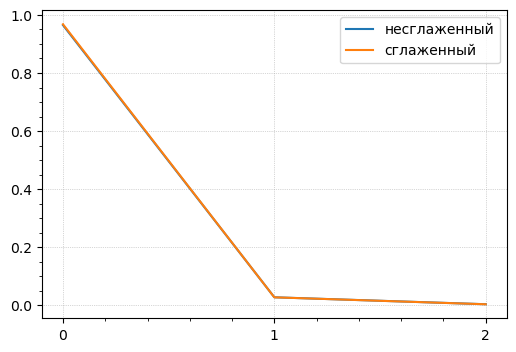

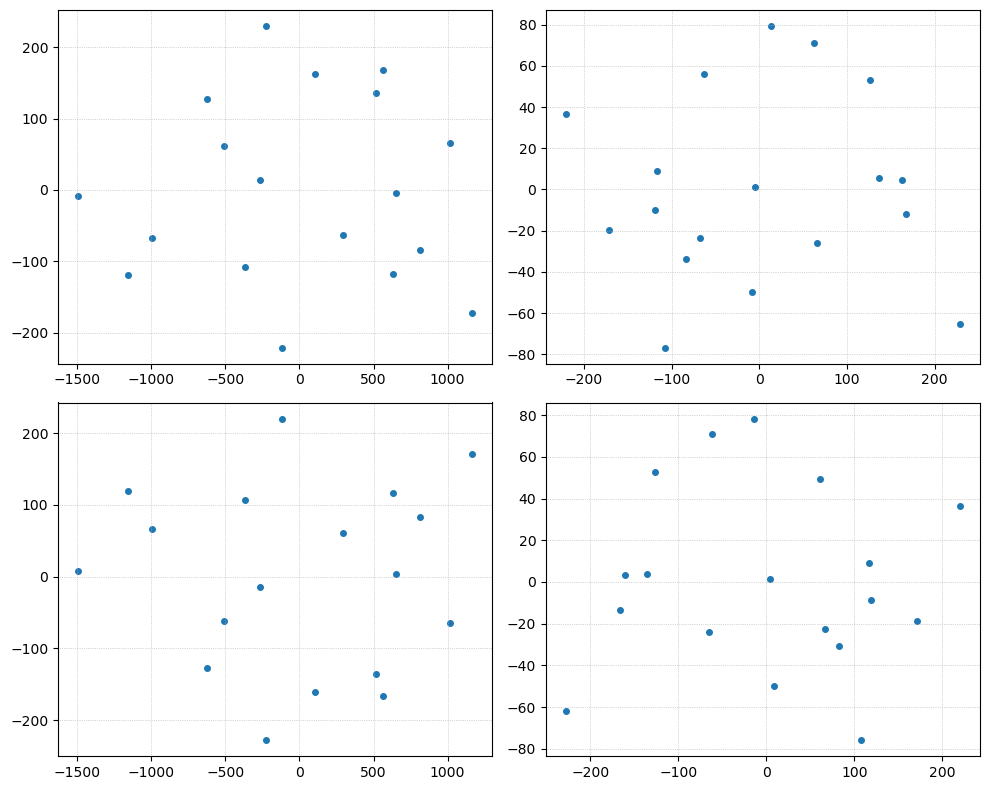

In [22]:
from sklearn.decomposition import PCA

zs = [smooth.whittaker_smooth(y, tau2=1.0, d=2) for y in ys]
pca_ys = PCA().fit(ys)
us_ys = pca_ys.transform(ys)
pca_zs = PCA().fit(zs)
us_zs = pca_zs.transform(zs)

plt.figure(figsize=(6,4))
plt.plot(pca_ys.explained_variance_ratio_[:3], label="несглаженный")
plt.plot(pca_zs.explained_variance_ratio_[:3], label="сглаженный")
plt.grid(ls=':', lw=0.5)
plt.minorticks_on()
plt.xticks([0,1,2])
plt.legend()
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.scatter(us_ys[:,0], us_ys[:,1], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,2)
plt.scatter(us_ys[:,1], us_ys[:,2], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,3)
plt.scatter(us_zs[:,0], us_zs[:,1], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,4)
plt.scatter(us_zs[:,1], us_zs[:,2], s=16)
plt.grid(ls=':', lw=0.5)
plt.tight_layout()
# plt.legend(
plt.show()

In [23]:
tau2_slider = ipywidgets.FloatSlider(value=1.0e6, min=0.0, max=1.0e8, step=100.0)
tau2_slider.layout.width="50%"
eps_slider = ipywidgets.FloatSlider(value=0.001, min=0.0, max=1.0, step=0.001, readout_format=".3f")
eps_slider.layout.width="50%"
delta_slider = ipywidgets.FloatSlider(value=1.0, min=0.0, max=10.0, step=0.1, readout_format=".1f")
delta_slider.layout.width="50%"

@ipywidgets.interact(tau2=tau2_slider, delta=delta_slider, eps=eps_slider, continuous_update=False)
def plot_baseline(tau2, delta, eps):
    if eps == 0:
        eps = 1.0e-4
    if delta == 0:
        delta = 1.0e-4
    y1 = y
    d=2
    # y1 /= y1.max()
    # y1 = smooth.whittaker_smooth(y, tau2=10.0, d=2)
    bl1, _ = smooth.whittaker_smooth_weight_func2(
            y1, 
            func=funcs.RStep(1.0e-6, eps=1.0e-6),
            func2_e=inventory.relative_abs_max,
            tau2=tau2, d=d)
    bl2, _ = smooth.whittaker_smooth_weight_func2(
            y1, 
            func=funcs.RStep(delta, eps=0),
            func2_e=inventory.relative_abs_max,
            tau2=tau2, d=d)
    bl3, _ = smooth.whittaker_smooth_weight_func2(
            y1, 
            func=funcs.RStep(0, eps=eps),
            func2_e=inventory.relative_abs_max,
            tau2=tau2, d=d)
    bl4, _ = smooth.whittaker_smooth_weight_func2(
            y1, func=smooth.func_aspls,
            func2_e=inventory.relative_abs_max,
            tau2=tau2, d=d)
    
    plt.figure(figsize=(12,7))
    plt.subplot(2,1,1)
    plt.title(r"Поиск базовой линии спектра: $\lambda=%.0f$ $\delta=%.3f$ $\epsilon=%.3f$" % (tau2, delta, eps))
    plt.plot(x, y1, color='k', linewidth=0.5,  ms=2.0, label="оригинал")
    plt.plot(x, bl1, linewidth=1.5, label=r"rsPLS ($\delta=10^{-6},\epsilon=10^{-6}$)")
    plt.plot(x, bl2, linewidth=1.5, label=r"rsPLS ($\epsilon=0$)")
    plt.plot(x, bl3, linewidth=1.5, label=r"rsPLS ($\delta=0$)")
    plt.plot(x, bl4, linewidth=1.5, label=r"asPLS")
    plt.minorticks_on()
    plt.grid(ls=':', lw=0.5)
    plt.legend()
    plt.subplot(2,1,2)    
    plt.title("Разность между спектром и его базовой линией")
    plt.plot(x, y1-bl1, linewidth=1.0, label=r"rsPLS ($\delta=10^{-6},\epsilon=10^{-6}$)")
    plt.plot(x, y1-bl2, linewidth=1.0, label=r"rsPLS ($\epsilon=0$)")
    plt.plot(x, y1-bl3, linewidth=1.0, label=r"rsPLS ($\delta=0$)")
    plt.plot(x, y1-bl4, linewidth=1.0, label=r"asPLS")
    plt.minorticks_on()
    plt.grid(ls=':', lw=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig/bl_step_aspls.eps")
    plt.show()

interactive(children=(FloatSlider(value=1000000.0, description='tau2', layout=Layout(width='50%'), max=1000000…

In [24]:

# alpha_slider = ipywidgets.FloatSlider(value=1.0, min=0.0, max=10.0, step=0.1, readout_format=".1f")
# alpha_slider.layout.width="50%"

@ipywidgets.interact(continuous_update=False)
def plot_baseline(alpha=1.0):
    bl1, _ = smooth.whittaker_smooth_weight_func2(
                y, 
                # func=funcs.Quantile(alpha),
                # func=funcs.Step(1.0e-5, eps=0.0),
                func=funcs.Gumbel(alpha),
                # func=funcs.Exp(-alpha),
                # func2=funcs.Step(0.000, eps=alpha),
                # func2=softabs_func.derivative_div_array,
                # func2_e=inventory.relative_abs_max,
                tau2=1000, d=2)
    yy1 = y - bl1
    plt.hist(yy1, bins=21)
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='alpha', max=3.0, min=-1.0), Output()), _dom_classes=…

In [25]:
# from scipy.stats import weibull_min, gumbel_r
# dist = weibull_min
# args = dist.fit(yy1)
# yy2 = np.sort(yy1)
# print(args)
# plt.plot(yy2,1-dist.cdf(yy2, *args))
# W = 1-dist.cdf(yy1, *args)

In [26]:
# bl2 = smooth.whittaker_smooth(y, W=W, tau2=1000)
# plt.figure(figsize=(12,4))
# plt.plot(x, y, lw=1.0, c='k')
# plt.plot(x, bl1, lw=1.0, label='1')
# plt.plot(x, bl2, lw=1.0, label='2')
# plt.plot(x, y-bl2, lw=1.0, label='2')
# plt.legend()
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


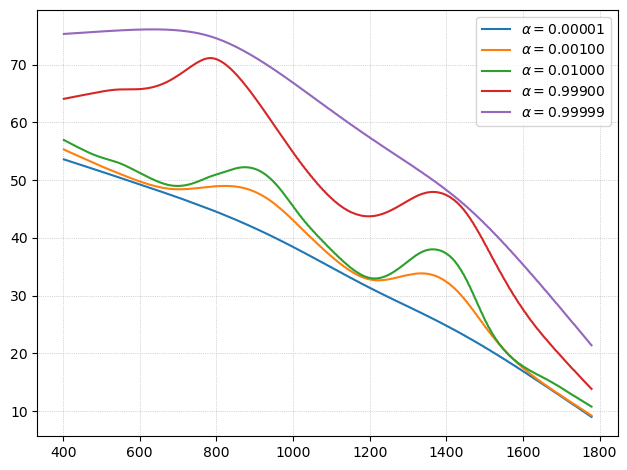

In [27]:
plt.figure(figsize=(10,4))
plt.plot(x, y, color='gray', linewidth=1.0,  ms=1.0, label="оригинал")
for alpha in [1.0e-5, 0.001, 0.01, 0.999, 1-1.0e-5]:
    bl, _ = smooth.whittaker_smooth_weight_func2(
        y, 
        func=funcs.Quantile(alpha),
        # func=funcs.Step(0, eps=0.001),
        # func=funcs.Weibul(alpha),
        # func=funcs.Exp(-0.5),
        # func2=funcs.Step(0.001, alpha),
        # func2_e=inventory.relative_abs_max,
        tau2=1.0e5, d=2)
    plt.plot(x, bl, linewidth=1.5, label=r"$\alpha=$"+f"{alpha:.5f}")
plt.legend()
plt.tight_layout()
plt.grid(ls=':', lw=0.5)
# plt.xlabel("t")
# plt.ylabel("x")
plt.savefig("fig/bl_asls_alpha.eps")
plt.show()


In [38]:
alpha_slider = ipywidgets.FloatSlider(value=0.1, min=0.0, max=10.0, step=0.1, readout_format=".4f")
alpha_slider.layout.width="50%"

@ipywidgets.interact(continuous_update=False)
def plot_baseline(tau2=1000.0, alpha=alpha_slider):
    # eps = 1.0e-3
    plt.figure(figsize=(12,5))
    plt.plot(x, y, color='gray', linewidth=1.0,  ms=1.0, label="оригинал")
    bl, _ = smooth.whittaker_smooth_weight_func2(
        y, 
        # func=funcs.RStep_Exp(alpha),
        # func=funcs.Quantile(alpha),
        func=funcs.RStep(alpha, 0),
        # func=funcs.Gumbel(alpha),
        # func=funcs.Exp(-0.5),
        # func2=funcs.Step(0, eps),
        # func2=softabs_func.derivative_div_array, 
        # func2_e=inventory.relative_abs_max,
        tau2=tau2, d=2)
    plt.plot(x, bl, linewidth=1.5, label=r"$\alpha=$"+f"{alpha:.5f}")
    plt.plot(x, y-bl, linewidth=1.5, label=r"bl")
    plt.legend()
    plt.tight_layout()
    plt.minorticks_on()
    plt.grid(ls=':', lw=0.5)
    # plt.xlim(600,1200)
    # plt.savefig("fig/bl_step_epsilon.eps")
    plt.show()


interactive(children=(FloatSlider(value=1000.0, description='tau2', max=3000.0, min=-1000.0), FloatSlider(valu…

In [29]:
@ipywidgets.interact(continuous_update=False)
def plot_func(xi=-4.0, ):
    if xi > 0:
        xr = np.linspace(-3,1/xi,100)
        y = (1 - xi*xr) ** (-1-1/xi)-(1+xi)/(1-xi*xr)
        plt.figure(figsize=(10,4))
        plt.plot(xr, y)
        plt.show()
    elif xi < 0:
        xr = np.linspace(-1/abs(xi),3,100)
        y = (1 - xi*xr) ** (-1-1/xi)-(1+xi)/(1-xi*xr)
        plt.figure(figsize=(10,4))
        plt.plot(xr, y)
        plt.show()
        


interactive(children=(FloatSlider(value=-4.0, description='xi', max=4.0, min=-12.0), Output()), _dom_classes=(…